In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [2]:
# Function to draw a box
def draw_box(ax, x, y, z, dx, dy, dz, color):
    vertices = [
        # Bottom
        [(x, y, z), (x+dx, y, z), (x+dx, y+dy, z), (x, y+dy, z)],
        # Top
        [(x, y, z+dz), (x+dx, y, z+dz), (x+dx, y+dy, z+dz), (x, y+dy, z+dz)],
        # Front
        [(x, y, z), (x+dx, y, z), (x+dx, y, z+dz), (x, y, z+dz)],
        # Back
        [(x, y+dy, z), (x+dx, y+dy, z), (x+dx, y+dy, z+dz), (x, y+dy, z+dz)],
        # Left
        [(x, y, z), (x, y+dy, z), (x, y+dy, z+dz), (x, y, z+dz)],
        # Right
        [(x+dx, y, z), (x+dx, y+dy, z), (x+dx, y+dy, z+dz), (x+dx, y, z+dz)],
    ]
    ax.add_collection3d(Poly3DCollection(vertices, alpha=0.3, facecolor=color))


In [6]:
# Read CSV
df = pd.read_csv("internship assignment.csv")
# Clean mm values → convert to int
def clean(val):
    return int(str(val).replace("mm", ""))
df["LenX"] = df["LenX"].apply(clean)
df["LenY"] = df["LenY"].apply(clean)
df["LenZ"] = df["LenZ"].apply(clean)
df["X"] = df["X"].apply(clean)
df["Y"] = df["Y"].apply(clean)
df["Z"] = df["Z"].apply(clean)


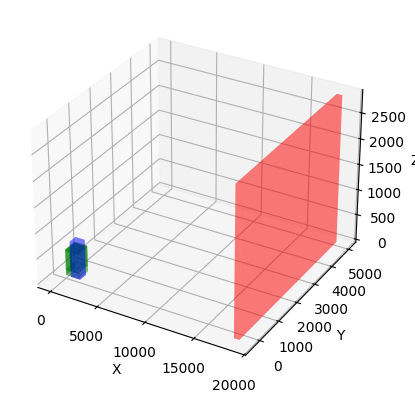

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for _, row in df.iterrows():
    level = row["Level"]
    if level == 0:
        color = 'red'
    elif level == 1:
        color = 'blue'
    else:
        color = 'green'
    draw_box(
        ax,
        row["X"], row["Y"], row["Z"],
        row["LenX"], row["LenY"], row["LenZ"],
        color
    )
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()